# Support Vector Machines and Kernel Methods

Notebook ini membahas **Support Vector Machines (SVM)** dan **kernel methods** untuk klasifikasi dan regresi. Fokus utama chapter ini adalah bagaimana SVM mencari decision boundary yang memaksimalkan margin, bagaimana kernel membantu menangani data non-linear, serta bagaimana hyperparameter seperti `C`, `kernel`, `degree`, dan `gamma` memengaruhi performa model.

Materi disusun dalam Bahasa Indonesia dengan penjelasan teori, rumus matematis dalam format Markdown/LaTeX yang benar, implementasi Python, visualisasi decision boundary, tuning parameter, dan evaluasi model.

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami konsep dasar Support Vector Machines.
- Menjelaskan hyperplane, margin, dan support vectors.
- Mengimplementasikan SVM untuk klasifikasi menggunakan `SVC`.
- Mengimplementasikan SVM untuk regresi menggunakan `SVR`.
- Memahami fungsi kernel seperti linear, polynomial, dan RBF.
- Membandingkan pengaruh kernel terhadap decision boundary.
- Melakukan hyperparameter tuning menggunakan `GridSearchCV`.
- Menjelaskan pengaruh parameter `C`, `degree`, dan `gamma`.
- Menerapkan SVM pada data berdimensi tinggi.
- Mengevaluasi performa SVM menggunakan accuracy, classification report, confusion matrix, MSE, dan R².

## Persiapan Library

Cell ini memuat seluruh library yang digunakan. Warning diabaikan agar output notebook tetap rapi saat dijalankan di Jupyter Notebook, VS Code, atau Google Colab.

In [21]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_classification, make_regression, make_moons
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

np.random.seed(2024)
pd.set_option("display.max_columns", 120)

## Ringkasan Chapter

Support Vector Machines adalah algoritma machine learning yang dapat digunakan untuk klasifikasi dan regresi. Pada klasifikasi, SVM mencari hyperplane terbaik yang memisahkan kelas dengan margin terbesar. Titik-titik data terdekat dengan hyperplane disebut **support vectors**, karena titik-titik inilah yang paling menentukan posisi decision boundary.

SVM juga kuat untuk data berdimensi tinggi dan dapat menangani data non-linear melalui kernel trick. Kernel memungkinkan model bekerja seolah-olah data dipetakan ke ruang berdimensi lebih tinggi tanpa benar-benar menghitung transformasi tersebut secara eksplisit.

Topik utama pada chapter ini:

| Topik | Inti Pembahasan |
|---|---|
| SVM Classification | Mencari hyperplane dengan margin terbesar |
| Support Vectors | Titik data yang menentukan decision boundary |
| Soft Margin | Mengizinkan sebagian kesalahan klasifikasi |
| Kernel Trick | Memetakan data ke ruang fitur lebih tinggi secara implisit |
| Linear Kernel | Kernel sederhana untuk data yang relatif linear |
| Polynomial Kernel | Kernel untuk pola interaksi polynomial |
| RBF Kernel | Kernel fleksibel untuk pola non-linear kompleks |
| Grid Search | Mencari kombinasi hyperparameter terbaik |
| High-Dimensional Data | SVM efektif pada dataset dengan fitur banyak |

## Introduction to Support Vector Machines

SVM adalah model yang mencari batas pemisah antar kelas. Dalam kasus dua dimensi, batas ini berbentuk garis. Dalam tiga dimensi, batasnya berbentuk bidang. Pada dimensi yang lebih tinggi, batas ini disebut **hyperplane**.

Tujuan SVM bukan hanya menemukan batas yang memisahkan kelas, tetapi menemukan batas yang memiliki jarak terbesar terhadap titik terdekat dari setiap kelas. Jarak ini disebut **margin**. Margin yang besar biasanya membuat model lebih stabil dan lebih mampu melakukan generalisasi pada data baru.

Konsep penting:

- **Hyperplane**: batas keputusan yang memisahkan kelas.
- **Margin**: jarak antara hyperplane dan support vectors.
- **Support vectors**: data training yang paling dekat dengan hyperplane.
- **Soft margin**: pendekatan yang memperbolehkan sebagian data salah klasifikasi agar model lebih fleksibel.

## Rumus Hyperplane

Pada SVM, hyperplane dapat ditulis sebagai:

$$
w^T x + b = 0
$$

Keterangan:

- $w$ = vektor bobot
- $x$ = vektor fitur
- $b$ = bias atau intercept

Untuk klasifikasi biner, prediksi kelas dapat ditentukan dari tanda fungsi keputusan:

$$
f(x) = w^T x + b
$$

Jika $f(x) > 0$, data masuk ke satu kelas. Jika $f(x) < 0$, data masuk ke kelas lainnya.

## Rumus Margin Maksimum

Margin pada SVM berhubungan dengan panjang vektor bobot $w$.

$$
Margin = \frac{2}{\|w\|}
$$

Karena margin ingin dibuat sebesar mungkin, maka SVM meminimalkan:

$$
\frac{1}{2}\|w\|^2
$$

dengan constraint:

$$
y_i(w^T x_i + b) \ge 1
$$

Keterangan:

- $y_i$ = label data ke-$i$, biasanya bernilai $-1$ atau $1$
- $x_i$ = fitur data ke-$i$
- $w$ = vektor bobot
- $b$ = bias

Intinya, SVM mencari hyperplane yang tidak hanya memisahkan kelas, tetapi juga memberi ruang terbesar antara kelas-kelas tersebut.

## Soft Margin SVM

Pada data nyata, kelas sering tidak dapat dipisahkan sempurna. Soft margin memperbolehkan sebagian data berada di sisi margin yang salah dengan menambahkan slack variable.

Rumus optimasi soft margin:

$$
\min \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\xi_i
$$

dengan constraint:

$$
y_i(w^T x_i + b) \ge 1 - \xi_i
$$

$$
\xi_i \ge 0
$$

Keterangan:

- $C$ = parameter regularisasi
- $\xi_i$ = slack variable untuk data ke-$i$
- $n$ = jumlah data

Jika $C$ besar, model lebih keras menghukum kesalahan klasifikasi. Jika $C$ kecil, model lebih toleran terhadap kesalahan dan menghasilkan margin yang lebih lebar.

## Load Dataset Iris

Dataset Iris digunakan sebagai contoh klasifikasi. Dataset ini memiliki 150 data, 4 fitur numerik, dan 3 kelas bunga.

In [22]:
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names

df_iris = pd.DataFrame(X, columns=feature_names)
df_iris["target"] = y
df_iris["species"] = df_iris["target"].map({i: name for i, name in enumerate(iris.target_names)})

print("Shape dataset:", df_iris.shape)
print("Target names:", iris.target_names)
df_iris.head()

Shape dataset: (150, 6)
Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Train-Test Split

Data dibagi menjadi training set dan test set. Parameter `stratify=y` digunakan agar proporsi kelas pada training dan test set tetap seimbang.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2024,
    stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 105
Jumlah data testing: 45


## SVM Classification dengan Linear Kernel

Linear kernel digunakan ketika data relatif dapat dipisahkan dengan batas linear. Pada contoh ini, `SVC(kernel="linear")` digunakan sebagai baseline SVM.

In [24]:
linear_svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear"))
])

linear_svm_pipe.fit(X_train, y_train)

y_pred_linear = linear_svm_pipe.predict(X_test)

linear_accuracy = accuracy_score(y_test, y_pred_linear)

print(f"Linear Kernel Accuracy: {linear_accuracy:.3f}")

linear_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_linear,
        target_names=iris.target_names,
        output_dict=True
    )
).transpose()

linear_report

Linear Kernel Accuracy: 0.978


,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,15.000000
versicolor,1.000000,0.933333,0.965517,15.000000
virginica,0.937500,1.000000,0.967742,15.000000
accuracy,0.977778,0.977778,0.977778,0.977778
macro avg,0.979167,0.977778,0.977753,45.000000
weighted avg,0.979167,0.977778,0.977753,45.000000


## Analisis Linear SVM

Linear SVM cukup efektif pada Iris dataset karena sebagian kelas memiliki pola yang relatif terpisah. Namun, untuk kelas yang distribusinya saling berdekatan, decision boundary linear bisa kurang fleksibel.

Hal penting dari SVM linear adalah interpretasinya lebih sederhana dibanding kernel non-linear. Namun, jika data memiliki pola melengkung atau interaksi kompleks antar fitur, kernel non-linear dapat memberikan hasil yang lebih baik.

## SVM Regression dengan SVR

Selain klasifikasi, SVM juga dapat digunakan untuk regresi melalui **Support Vector Regression (SVR)**. SVR mencoba mencari fungsi yang memprediksi nilai kontinu dengan toleransi error tertentu.

Pada SVR, parameter penting yang sering digunakan adalah:

- `C`: mengontrol penalti error.
- `epsilon`: batas toleransi error.
- `kernel`: fungsi kernel yang digunakan.

## Rumus Intuisi SVR

SVR menggunakan konsep epsilon-insensitive loss. Error kecil yang masih berada dalam rentang $\epsilon$ tidak diberi penalti.

$$
L_\epsilon(y, \hat{y}) =
\max(0, |y - \hat{y}| - \epsilon)
$$

Keterangan:

- $y$ = nilai aktual
- $\hat{y}$ = nilai prediksi
- $\epsilon$ = batas toleransi error

Jika selisih prediksi dan aktual masih lebih kecil dari $\epsilon$, loss bernilai 0. Jika lebih besar, selisih di luar $\epsilon$ akan diberi penalti.

In [25]:
X_reg, y_reg = make_regression(
    n_samples=400,
    n_features=2,
    noise=15,
    random_state=2024
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.3,
    random_state=2024
)

svr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=10, epsilon=0.1))
])

svr_pipe.fit(X_train_reg, y_train_reg)

y_pred_reg = svr_pipe.predict(X_test_reg)

mse = mean_squared_error(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

pd.DataFrame({
    "Metric": ["MSE", "MAE", "R2"],
    "Value": [mse, mae, r2]
})

,Metric,Value
0,MSE,321.493965
1,MAE,13.090217
2,R2,0.809787


## Visualisasi SVR

Visualisasi berikut membandingkan nilai aktual dan prediksi. Jika model baik, titik-titik akan mendekati garis diagonal.

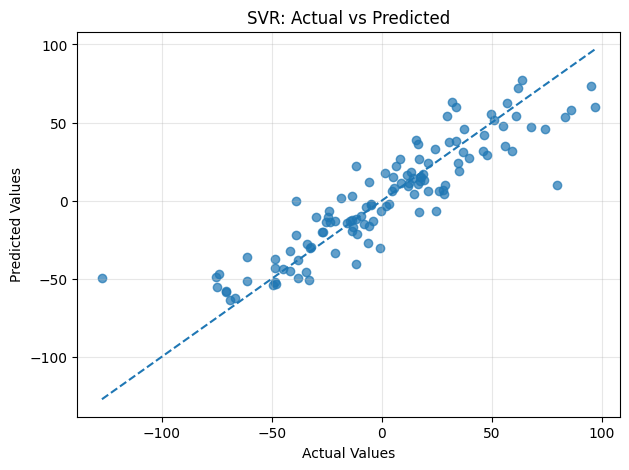

In [26]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.7)
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR: Actual vs Predicted")
plt.grid(alpha=0.3)
plt.show()

## Kernel Functions and Their Applications

Kernel adalah fungsi yang menghitung kemiripan antara dua data. Dalam SVM, kernel digunakan untuk membentuk decision boundary non-linear tanpa harus menghitung transformasi fitur secara eksplisit.

Kernel trick memungkinkan SVM bekerja seolah-olah data berada pada ruang dimensi lebih tinggi. Pada ruang baru tersebut, data yang awalnya sulit dipisahkan dapat menjadi lebih mudah dipisahkan menggunakan hyperplane.

Jenis kernel umum:

| Kernel | Kegunaan |
|---|---|
| Linear | Data relatif linear |
| Polynomial | Data memiliki interaksi polynomial antar fitur |
| RBF | Data memiliki pola non-linear kompleks |
| Sigmoid | Beberapa kasus khusus yang menyerupai aktivasi neural network |

## Rumus Kernel Linear

Linear kernel adalah bentuk kernel paling sederhana.

$$
K(x_i, x_j) = x_i^T x_j
$$

Keterangan:

- $x_i$ = data pertama
- $x_j$ = data kedua
- $x_i^T x_j$ = dot product antara dua vektor fitur

Linear kernel cocok digunakan ketika data dapat dipisahkan secara linear atau ketika jumlah fitur sangat besar.

## Rumus Kernel Polynomial

Polynomial kernel memetakan data ke ruang fitur yang mengandung kombinasi polynomial.

$$
K(x_i, x_j) = (\gamma x_i^T x_j + c)^d
$$

Keterangan:

- $\gamma$ = parameter skala
- $c$ = konstanta
- $d$ = degree polynomial
- $x_i^T x_j$ = dot product antar data

Semakin tinggi nilai $d$, semakin kompleks decision boundary yang dapat dibentuk. Namun, degree terlalu tinggi dapat meningkatkan risiko overfitting.

## Rumus Kernel RBF

RBF atau Radial Basis Function kernel menggunakan fungsi Gaussian untuk mengukur kemiripan.

$$
K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)
$$

Keterangan:

- $\gamma$ = parameter yang mengatur jangkauan pengaruh satu data
- $\|x_i - x_j\|^2$ = jarak kuadrat antara dua data

Jika $\gamma$ besar, pengaruh setiap data menjadi sangat lokal sehingga model bisa terlalu kompleks. Jika $\gamma$ kecil, decision boundary menjadi lebih halus.

## Membandingkan Kernel pada Iris Dataset

Bagian ini membandingkan tiga kernel utama: linear, polynomial, dan RBF.

In [27]:
kernel_results = []
kernel_models = {}

for kernel_name in ["linear", "poly", "rbf"]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel=kernel_name, degree=3))
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    kernel_models[kernel_name] = pipe
    kernel_results.append({
        "Kernel": kernel_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Macro F1": classification_report(y_test, pred, output_dict=True)["macro avg"]["f1-score"],
        "Weighted F1": classification_report(y_test, pred, output_dict=True)["weighted avg"]["f1-score"]
    })

kernel_results_df = pd.DataFrame(kernel_results).sort_values("Accuracy", ascending=False)
kernel_results_df

,Kernel,Accuracy,Macro F1,Weighted F1
0,linear,0.977778,0.977753,0.977753
2,rbf,0.933333,0.933259,0.933259
1,poly,0.888889,0.885714,0.885714


## Analisis Perbandingan Kernel

Pada dataset sederhana seperti Iris, perbedaan performa antar kernel bisa tidak terlalu besar. Namun, perbedaan kecil tetap penting untuk dianalisis karena pada kasus nyata, kesalahan klasifikasi dapat memiliki dampak besar.

Interpretasi umum:

- Linear kernel lebih sederhana dan mudah dikontrol.
- Polynomial kernel bisa menangkap interaksi fitur.
- RBF kernel lebih fleksibel untuk pola non-linear.
- Kernel yang lebih kompleks tidak selalu lebih baik jika data sudah cukup sederhana.

## Visualizing SVM Decision Boundaries

Decision boundary membantu melihat bagaimana model membagi ruang fitur menjadi beberapa kelas. Karena visualisasi hanya dapat dilakukan dengan mudah dalam 2D, contoh berikut menggunakan dua fitur Iris: petal length dan petal width.

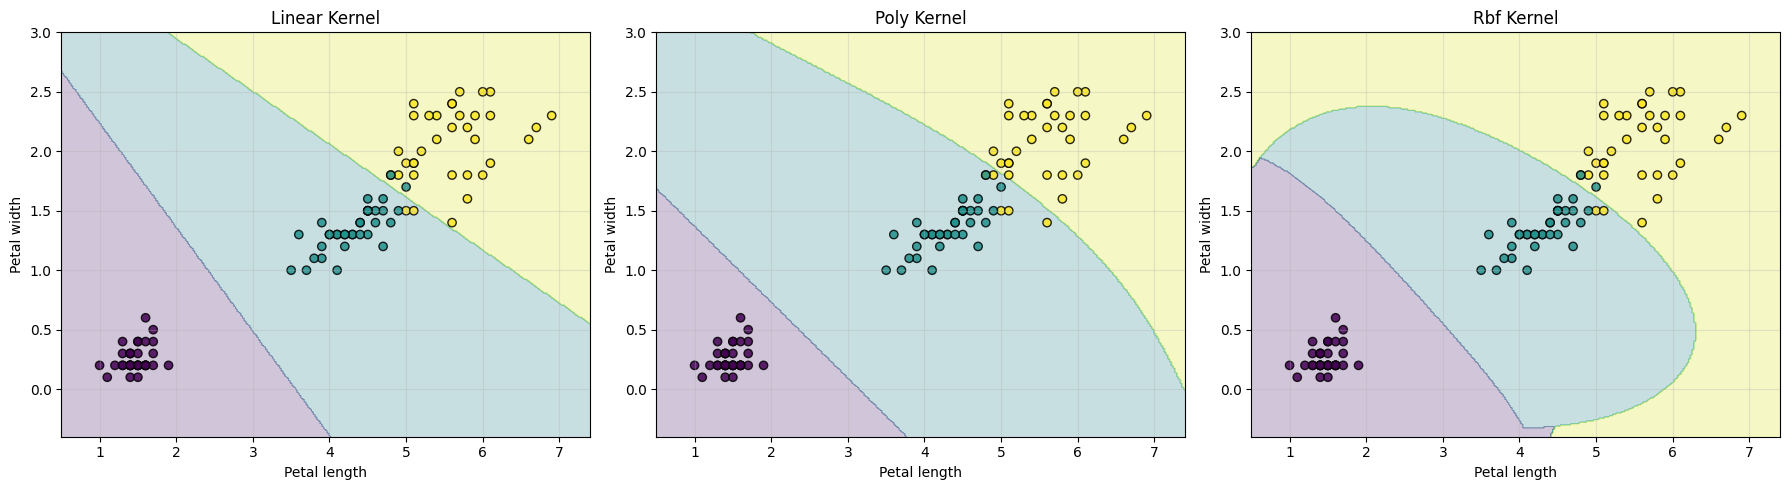

In [28]:
X_2d = X[:, [2, 3]]
y_2d = y

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.3,
    random_state=2024,
    stratify=y_2d
)

def plot_decision_boundary(model, X_data, y_data, title):
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data, edgecolor="black", alpha=0.85)
    plt.xlabel("Petal length")
    plt.ylabel("Petal width")
    plt.title(title)
    plt.grid(alpha=0.3)

models_2d = {}

for kernel_name in ["linear", "poly", "rbf"]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel=kernel_name, degree=3))
    ])
    model.fit(X_train_2d, y_train_2d)
    models_2d[kernel_name] = model

plt.figure(figsize=(18, 5))

for i, kernel_name in enumerate(["linear", "poly", "rbf"], start=1):
    plt.subplot(1, 3, i)
    plot_decision_boundary(
        models_2d[kernel_name],
        X_train_2d,
        y_train_2d,
        f"{kernel_name.capitalize()} Kernel"
    )

plt.tight_layout()
plt.show()

## Analisis Decision Boundary

Visualisasi decision boundary menunjukkan bahwa kernel berbeda dapat menghasilkan batas klasifikasi yang berbeda.

- Linear kernel menghasilkan batas yang cenderung lurus.
- Polynomial kernel dapat membentuk boundary yang sedikit melengkung.
- RBF kernel cenderung lebih fleksibel dan dapat membentuk boundary non-linear yang lebih halus.

Namun, visualisasi ini hanya menggunakan dua fitur. Pada model yang menggunakan semua fitur, decision boundary sebenarnya berada pada ruang berdimensi lebih tinggi.

## Tuning SVM Parameters

SVM memiliki beberapa hyperparameter penting. Pemilihan nilai hyperparameter sangat memengaruhi performa model.

| Parameter | Fungsi |
|---|---|
| `C` | Mengontrol trade-off antara margin dan kesalahan klasifikasi |
| `kernel` | Menentukan bentuk transformasi data |
| `degree` | Degree polynomial untuk kernel poly |
| `gamma` | Mengatur jangkauan pengaruh data pada kernel RBF/poly |
| `class_weight` | Membantu menangani class imbalance |

Tuning dilakukan untuk mencari kombinasi parameter yang paling baik berdasarkan cross-validation.

## Rumus Pengaruh C dan Slack Variable

Pada soft margin SVM, parameter $C$ mengontrol besar penalti terhadap kesalahan klasifikasi.

$$
\min \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\xi_i
$$

Jika $C$ besar, model berusaha mengurangi kesalahan pada training set, tetapi bisa lebih mudah overfitting. Jika $C$ kecil, model lebih toleran terhadap kesalahan dan margin dapat menjadi lebih lebar.

## Grid Search dengan Cross-Validation

Grid search mencoba seluruh kombinasi parameter yang diberikan. Cross-validation digunakan agar pemilihan parameter tidak bergantung pada satu pembagian data saja.

In [29]:
param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 100]
    },
    {
        "model__kernel": ["poly"],
        "model__C": [0.1, 1, 10, 100],
        "model__degree": [2, 3, 4],
        "model__gamma": ["scale", "auto"]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": [0.01, 0.1, 1, "scale"]
    }
]

svm_grid_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

grid_search = GridSearchCV(
    svm_grid_pipe,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV score: {grid_search.best_score_:.3f}")
print(f"Test score: {grid_search.score(X_test, y_test):.3f}")

Best parameters: {'model__C': 1, 'model__kernel': 'linear'}
Best CV score: 1.000
Test score: 0.978


In [30]:
grid_results = pd.DataFrame(grid_search.cv_results_)

display_cols = [
    "param_model__kernel",
    "param_model__C",
    "param_model__degree",
    "param_model__gamma",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

grid_results[display_cols].sort_values("rank_test_score").head(10)

,param_model__kernel,param_model__C,param_model__degree,param_model__gamma,mean_test_score,std_test_score,rank_test_score
1,linear,1.0,NaN,NaN,1.000000,0.000000,1
37,rbf,10.0,NaN,0.1,1.000000,0.000000,1
40,rbf,100.0,NaN,0.01,1.000000,0.000000,1
39,rbf,10.0,NaN,scale,0.980952,0.023328,4
34,rbf,1.0,NaN,1,0.980952,0.023328,4
25,poly,100.0,3.0,auto,0.971429,0.023328,6
24,poly,100.0,3.0,scale,0.971429,0.023328,6
41,rbf,100.0,NaN,0.1,0.971429,0.023328,6
35,rbf,1.0,NaN,scale,0.971429,0.023328,6
38,rbf,10.0,NaN,1,0.961905,0.035635,10


## Analisis Hasil Grid Search

Grid search menghasilkan kombinasi parameter terbaik berdasarkan cross-validation. Namun, jika performa model terbaik hampir sama dengan model default, hal itu tidak selalu berarti tuning gagal. Bisa saja dataset memang cukup sederhana sehingga model default sudah bekerja baik.

Hal yang perlu diperhatikan:

- `best_score_` adalah performa rata-rata pada validasi, bukan test set.
- Test set tetap diperlukan untuk evaluasi akhir.
- Semakin banyak parameter dicoba, semakin lama proses komputasi.
- Search space yang terlalu besar dapat membuat tuning tidak efisien.

## Visualizing Hyperparameter Effects: Pengaruh C

Bagian ini melihat bagaimana nilai $C$ memengaruhi performa SVM dengan kernel RBF.

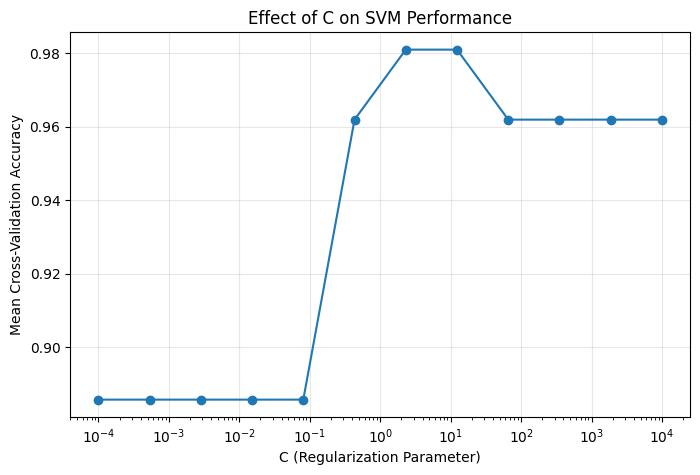

,C,Mean CV Accuracy
0,0.000100,0.885714
1,0.000534,0.885714
2,0.002848,0.885714
3,0.015199,0.885714
4,0.081113,0.885714
5,0.432876,0.961905
6,2.310130,0.980952
7,12.328467,0.980952
8,65.793322,0.961905
9,351.119173,0.961905


In [31]:
C_values = np.logspace(-4, 4, 12)

param_grid_c = {
    "model__C": C_values,
    "model__kernel": ["rbf"],
    "model__gamma": ["scale"]
}

grid_search_c = GridSearchCV(
    svm_grid_pipe,
    param_grid_c,
    cv=5,
    scoring="accuracy"
)

grid_search_c.fit(X_train, y_train)

c_scores = grid_search_c.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(C_values, c_scores, marker="o")
plt.xscale("log")
plt.xlabel("C (Regularization Parameter)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("Effect of C on SVM Performance")
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({
    "C": C_values,
    "Mean CV Accuracy": c_scores
})

## Analisis Pengaruh C

Ketika nilai $C$ terlalu kecil, model terlalu toleran terhadap kesalahan sehingga dapat mengalami underfitting. Ketika $C$ terlalu besar, model terlalu berusaha mengklasifikasikan data training dengan benar sehingga dapat menjadi terlalu kompleks.

Pada praktiknya, nilai $C$ yang baik biasanya ditemukan melalui cross-validation. Grafik membantu melihat apakah peningkatan performa sudah mencapai plateau atau masih berubah signifikan.

## Pengaruh Gamma pada RBF Kernel

Parameter $\gamma$ mengatur seberapa jauh pengaruh satu data training.

Rumus RBF kernel:

$$
K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)
$$

Interpretasi:

- $\gamma$ kecil: pengaruh data lebih luas, boundary lebih halus.
- $\gamma$ besar: pengaruh data lebih lokal, boundary lebih kompleks.

Jika $\gamma$ terlalu besar, model dapat overfitting.

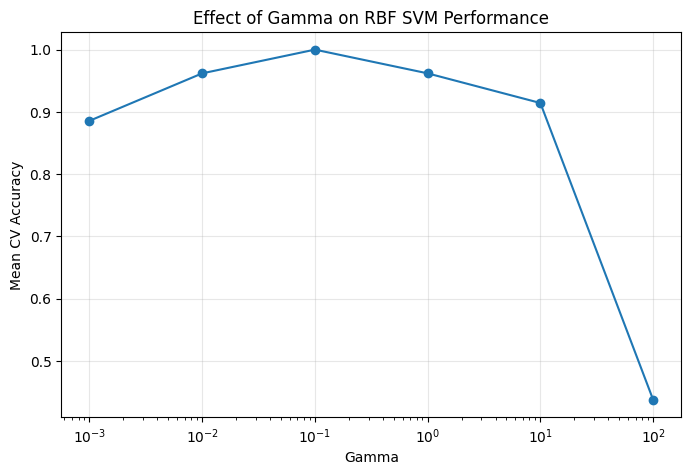

,gamma,Mean CV Accuracy
0,0.001,0.885714
1,0.010,0.961905
2,0.100,1.000000
3,1.000,0.961905
4,10.000,0.914286
5,100.000,0.438095


In [32]:
gamma_values = [0.001, 0.01, 0.1, 1, 10, 100]
gamma_scores = []

for gamma in gamma_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma=gamma))
    ])
    score = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy").mean()
    gamma_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(gamma_values, gamma_scores, marker="o")
plt.xscale("log")
plt.xlabel("Gamma")
plt.ylabel("Mean CV Accuracy")
plt.title("Effect of Gamma on RBF SVM Performance")
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({
    "gamma": gamma_values,
    "Mean CV Accuracy": gamma_scores
})

## SVMs in High-Dimensional Spaces

SVM sering efektif pada data berdimensi tinggi, terutama ketika jumlah fitur besar dibandingkan jumlah sampel. Contohnya dapat muncul pada data teks, genomik, atau data hasil pengukuran sensor yang memiliki banyak fitur.

Namun, data berdimensi tinggi juga memiliki tantangan:

- Risiko overfitting meningkat.
- Jarak antar data bisa menjadi kurang informatif.
- Waktu komputasi dapat meningkat.
- Scaling menjadi semakin penting.

## Dataset Sintetis Berdimensi Tinggi

Dataset berikut dibuat dengan 200 fitur, tetapi hanya sebagian fitur yang benar-benar informatif. Tujuannya adalah melihat bagaimana SVM bekerja pada data wide/high-dimensional.

In [33]:
X_high, y_high = make_classification(
    n_samples=500,
    n_features=200,
    n_informative=20,
    n_redundant=20,
    n_classes=2,
    random_state=2024
)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_high,
    y_high,
    test_size=0.3,
    random_state=2024,
    stratify=y_high
)

print("Shape data high-dimensional:", X_high.shape)
print("Jumlah fitur:", X_high.shape[1])

Shape data high-dimensional: (500, 200)
Jumlah fitur: 200


In [34]:
high_dim_models = {
    "Linear SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(C=1.0, max_iter=10000))
    ]),
    "RBF SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma="scale"))
    ])
}

high_dim_results = []

for name, model in high_dim_models.items():
    model.fit(X_train_h, y_train_h)
    pred = model.predict(X_test_h)
    high_dim_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_h, pred),
        "Macro F1": classification_report(y_test_h, pred, output_dict=True)["macro avg"]["f1-score"]
    })

pd.DataFrame(high_dim_results)

,Model,Accuracy,Macro F1
0,Linear SVC,0.646667,0.645896
1,RBF SVC,0.726667,0.726070


## Analisis High-Dimensional SVM

Pada data berdimensi tinggi, linear SVM sering menjadi baseline yang kuat karena banyak fitur dapat memberikan informasi pemisahan kelas. Kernel RBF tetap fleksibel, tetapi dapat menjadi lebih mahal secara komputasi dan lebih sensitif terhadap parameter.

Jika data sangat besar, `LinearSVC` sering lebih efisien dibanding `SVC(kernel="linear")`.

## Evaluating SVM Models

Evaluasi SVM tidak cukup hanya dengan accuracy. Kita juga perlu melihat confusion matrix, precision, recall, F1-score, dan performa cross-validation.

Untuk kasus klasifikasi multi-class seperti Iris, classification report dapat membantu membandingkan performa tiap kelas.

In [35]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=[f"True {name}" for name in iris.target_names],
    columns=[f"Predicted {name}" for name in iris.target_names]
)

cm_df

,Predicted setosa,Predicted versicolor,Predicted virginica
True setosa,15,0,0
True versicolor,0,14,1
True virginica,0,0,15


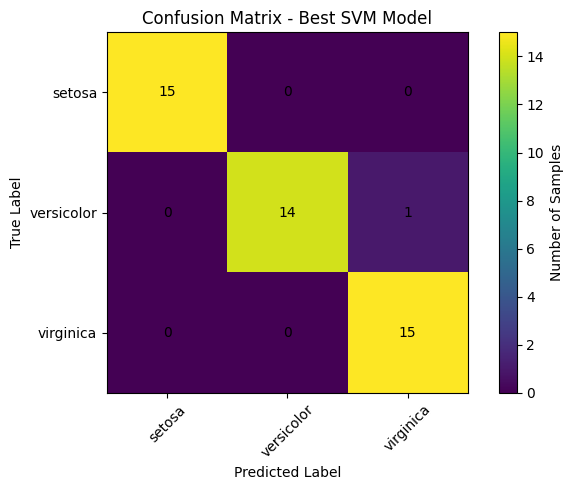

In [36]:
plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Best SVM Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(iris.target_names)), iris.target_names, rotation=45)
plt.yticks(np.arange(len(iris.target_names)), iris.target_names)
plt.colorbar(label="Number of Samples")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [37]:
best_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_best,
        target_names=iris.target_names,
        output_dict=True
    )
).transpose()

best_report

,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,15.000000
versicolor,1.000000,0.933333,0.965517,15.000000
virginica,0.937500,1.000000,0.967742,15.000000
accuracy,0.977778,0.977778,0.977778,0.977778
macro avg,0.979167,0.977778,0.977753,45.000000
weighted avg,0.979167,0.977778,0.977753,45.000000


## Cross-Validation Model Terbaik

Cross-validation digunakan untuk melihat stabilitas performa model pada beberapa pembagian data.

In [38]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print(f"Mean CV accuracy: {cv_scores.mean():.3f}")
print(f"Standard deviation: {cv_scores.std():.3f}")

Cross-validation scores: [0.96666667 1.         0.93333333 0.93333333 1.        ]
Mean CV accuracy: 0.967
Standard deviation: 0.030


## Studi Kasus Non-Linear: Make Moons Dataset

Dataset `make_moons` digunakan untuk menunjukkan kelebihan kernel non-linear. Dataset ini memiliki pola melengkung sehingga linear kernel biasanya kurang fleksibel.

In [39]:
X_moons, y_moons = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=2024
)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons,
    y_moons,
    test_size=0.3,
    random_state=2024,
    stratify=y_moons
)

moon_models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear"))
    ]),
    "Polynomial": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="poly", degree=3, C=10))
    ]),
    "RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale"))
    ])
}

moon_results = []

for name, model in moon_models.items():
    model.fit(X_train_m, y_train_m)
    pred = model.predict(X_test_m)
    moon_results.append({
        "Kernel": name,
        "Accuracy": accuracy_score(y_test_m, pred),
        "Macro F1": classification_report(y_test_m, pred, output_dict=True)["macro avg"]["f1-score"]
    })

pd.DataFrame(moon_results).sort_values("Accuracy", ascending=False)

,Kernel,Accuracy,Macro F1
2,RBF,0.933333,0.933315
1,Polynomial,0.841667,0.841568
0,Linear,0.833333,0.833287


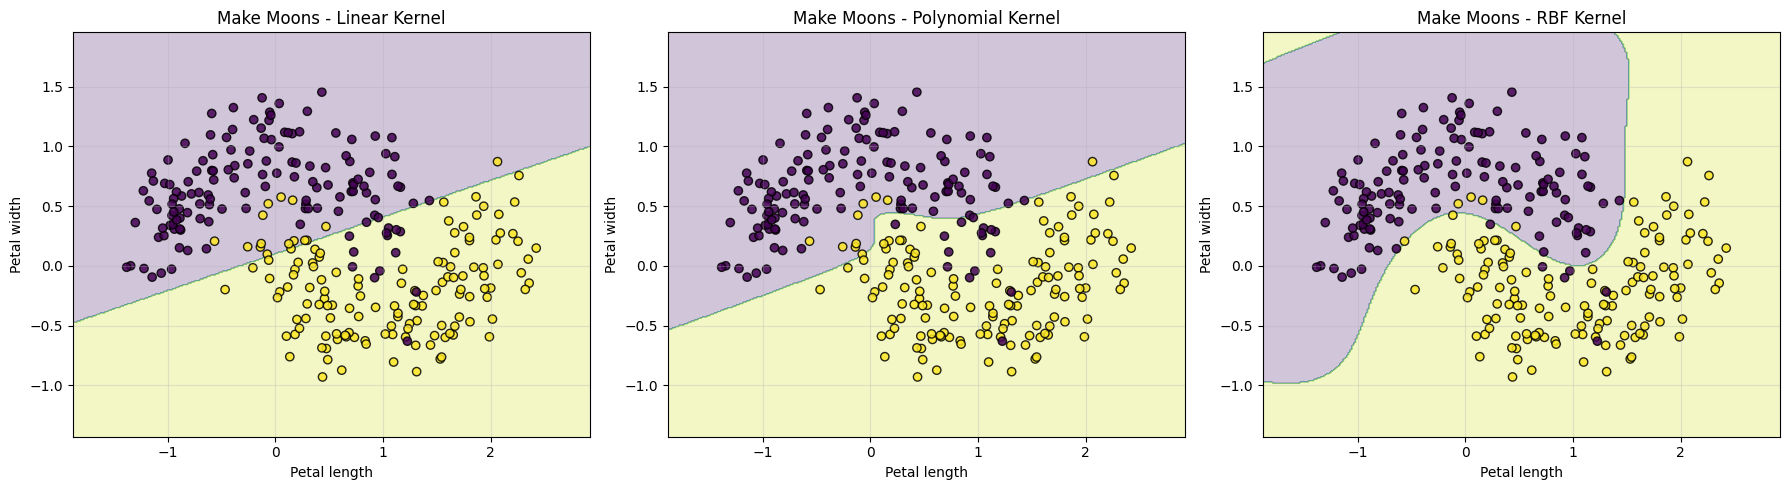

In [40]:
plt.figure(figsize=(18, 5))

for idx, (name, model) in enumerate(moon_models.items(), start=1):
    plt.subplot(1, 3, idx)
    plot_decision_boundary(model, X_train_m, y_train_m, f"Make Moons - {name} Kernel")

plt.tight_layout()
plt.show()

## Analisis Studi Kasus Non-Linear

Pada dataset non-linear seperti make moons, RBF dan polynomial kernel biasanya lebih baik dibanding linear kernel karena boundary yang dibutuhkan tidak berbentuk garis lurus.

Studi kasus ini menunjukkan inti dari kernel methods: data yang sulit dipisahkan pada ruang asli dapat menjadi lebih mudah dipisahkan setelah dipetakan ke representasi yang lebih kompleks.

## Ringkasan Konsep Penting

| Konsep | Penjelasan |
|---|---|
| SVM | Model yang mencari decision boundary dengan margin terbesar |
| Hyperplane | Batas pemisah antar kelas |
| Support Vectors | Titik terdekat yang menentukan hyperplane |
| Margin | Jarak antara hyperplane dan support vectors |
| Soft Margin | Mengizinkan sebagian kesalahan klasifikasi |
| C | Mengatur trade-off antara margin dan error |
| Kernel Trick | Menghitung kemiripan pada ruang fitur lebih tinggi secara implisit |
| Linear Kernel | Kernel sederhana berbasis dot product |
| Polynomial Kernel | Kernel untuk pola polynomial |
| RBF Kernel | Kernel non-linear berbasis fungsi Gaussian |
| Gamma | Mengatur jangkauan pengaruh data pada RBF |
| Grid Search | Mencoba kombinasi hyperparameter secara sistematis |
| SVR | Versi SVM untuk regresi |

## Kesimpulan Chapter

Chapter ini menunjukkan bahwa Support Vector Machines merupakan model yang kuat untuk klasifikasi dan regresi, terutama ketika data memiliki dimensi tinggi atau batas antar kelas tidak sederhana. SVM bekerja dengan mencari hyperplane yang memaksimalkan margin terhadap support vectors.

Poin penting dari chapter ini:

- SVM mencari decision boundary dengan margin terbesar.
- Support vectors adalah titik data yang paling menentukan posisi hyperplane.
- Soft margin membuat SVM lebih fleksibel terhadap data yang tidak sepenuhnya separable.
- Kernel trick memungkinkan SVM menangani data non-linear.
- Linear kernel cocok untuk data yang relatif linear.
- Polynomial kernel cocok untuk pola hubungan polynomial.
- RBF kernel fleksibel untuk data non-linear kompleks.
- Parameter `C`, `gamma`, dan `degree` sangat memengaruhi performa model.
- GridSearchCV membantu memilih hyperparameter terbaik.
- SVM dapat bekerja baik pada data berdimensi tinggi, tetapi scaling dan tuning tetap penting.
- Evaluasi model perlu menggunakan classification report, confusion matrix, dan cross-validation.

Secara keseluruhan, SVM adalah algoritma yang kuat, tetapi performanya sangat bergantung pada pemilihan kernel, preprocessing, dan hyperparameter tuning.